In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Improve plot appearance
plt.style.use("ggplot")

In [3]:
clinical = pd.read_csv(
    "../data/clinicalVariants/clinicalVariants.tsv",
    sep="\t"
)

clinical.head()

,variant,gene,type,level of evidence,chemicals,phenotypes
0,"CYP2C9*1, CYP2C9*3, CYP2C9*13",CYP2C9,Metabolism/PK,1A,lornoxicam,NaN
1,rs17376848,DPYD,Toxicity,1A,capecitabine,Neoplasms
2,rs2297595,DPYD,Toxicity,1A,capecitabine,Neoplasms
3,rs1801265,DPYD,Toxicity,1A,capecitabine,Neoplasms
4,"CYP2C19*1, CYP2C19*2, CYP2C19*3",CYP2C19,Metabolism/PK,1A,dexlansoprazole,NaN


In [4]:
clinical.shape

(5190, 6)

In [5]:
clinical.columns

Index(['variant', 'gene', 'type', 'level of evidence', 'chemicals',
       'phenotypes'],
      dtype='object')

In [6]:
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   variant            5190 non-null   object
 1   gene               4936 non-null   object
 2   type               5190 non-null   object
 3   level of evidence  5190 non-null   object
 4   chemicals          5190 non-null   object
 5   phenotypes         4175 non-null   object
dtypes: object(6)
memory usage: 243.4+ KB


In [7]:
clinical.isnull().sum()

variant                 0
gene                  254
type                    0
level of evidence       0
chemicals               0
phenotypes           1015
dtype: int64

In [8]:
top_genes = clinical["gene"].value_counts()

top_genes.head(15)

gene
ABCB1      248
OPRM1      133
CYP2D6     122
SLCO1B1     96
HLA-B       89
DPYD        82
CFTR        78
CYP2C19     77
CYP2C9      74
CYP3A4      69
COMT        67
CYP3A5      64
CYP2B6      62
DRD2        54
ABCG2       53
Name: count, dtype: int64

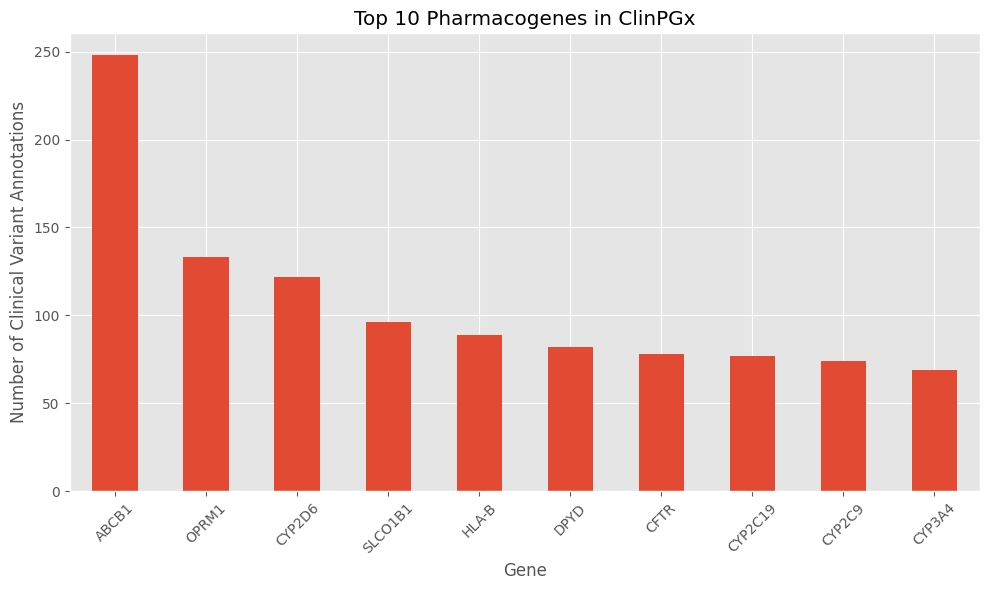

In [9]:
top10 = clinical["gene"].value_counts().head(10)

plt.figure(figsize=(10,6))

top10.plot(kind="bar")

plt.title("Top 10 Pharmacogenes in ClinPGx")
plt.xlabel("Gene")
plt.ylabel("Number of Clinical Variant Annotations")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [12]:
clinical["level of evidence"].value_counts()

level of evidence
3     4477
1A     314
4      310
2A      46
2B      25
1B      18
Name: count, dtype: int64

In [17]:
drug_counts = clinical["chemicals"].value_counts()

drug_counts.head(15)

chemicals
methotrexate                                          138
nicotine                                              107
methadone                                              98
ethanol                                                92
warfarin                                               89
opioids                                                84
fluorouracil                                           75
tacrolimus                                             74
duloxetine                                             73
risperidone                                            66
nevirapine                                             66
Tumor necrosis factor alpha (TNF-alpha) inhibitors     59
aspirin                                                58
olanzapine                                             56
Platinum compounds                                     52
Name: count, dtype: int64

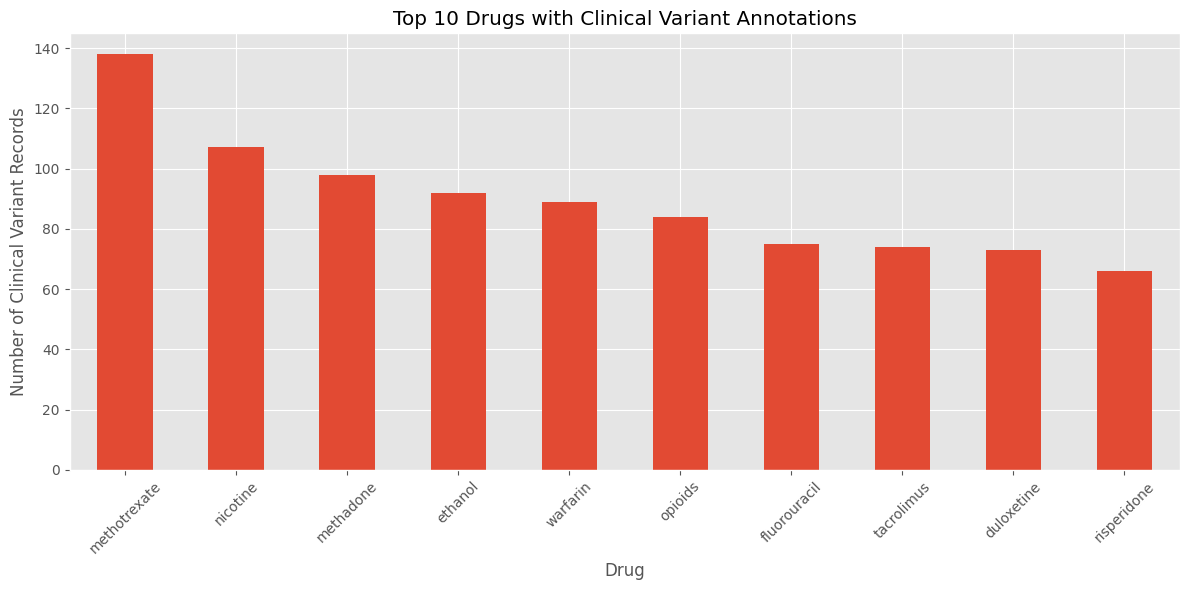

In [18]:
top10_drugs = drug_counts.head(10)

plt.figure(figsize=(12,6))

top10_drugs.plot(kind="bar")

plt.title("Top 10 Drugs with Clinical Variant Annotations")

plt.xlabel("Drug")

plt.ylabel("Number of Clinical Variant Records")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../figures/top10_drugs.png")

plt.show()